### <font color='#F5DEB3'> 1. Подключение библиотек и первичный анализ данных

*№ варианта (по списку):* **20**.

*Вариант типа поверхности:* **5**.

*Вариант датасета:* **[V1; V3]**.

Перед началом работы с **MLPClassifier** необходимо провести анализ данных, с которыми мы будем работать. Процесс обработки датасета содержит следующие этапы:
1. Расчёт множества {V3} и добавление датасета к V1.
2. Проведение бинарного преобразования для типа поверхности.
3. Построение матрицы корреляции, анализ физической зависимости данных.
4. Финальная обработка датасета и сохранение двух вариантов датасета (до и после обработки).

Сохранение двух датасетов позволит исследовать, как обработка датасета повлияла на точность модели **MLPClassifier**.

In [66]:
import os                          # Взаимодействие с операционной системой
import yaml                        # Чтение и запись данных в формате YAML

import pandas as pd                # Работа с табличными данными (excel)
import numpy as np                 # Работа с многомерными массивами, математические операции
import matplotlib.pyplot as plt    # Построение графиков и визуализация
import seaborn as sns              # Надстройка над matplotlib для красивой визуализации

In [67]:
# Загрузка параметров из yaml-файла
with open('C:/ML_Labs/LB3_ML_Yakushev/config/parameters.yaml', 'r', encoding='utf-8') as config_file:
    config = yaml.safe_load(config_file)

# Меняем рабочую директорию
os.chdir(config['base']['root_project_dir'])

print(config)

{'base': {'random_state': 42, 'root_project_dir': 'C:/ML_Labs/LB3_ML_Yakushev'}, 'robot': {'dist_center': 0.125, 'wheel_angle': 30, 'wheel_radius': 0.04}, 'data': {'dataset_xlsx': 'data/Data_Set_(A+B).xlsx', 'dataset_processed': 'data/processed/Data_Set_AB_processed.xlsx', 'dataset_test_xlsx': 'data/Data_Set_C.xlsx', 'target_column': 'Type', 'val_size': 0.2, 'type_space': 5}, 'MLP': {'model_params': {'cv_folds': 4}}}


In [68]:
V1 = pd.read_excel(config['data']['dataset_xlsx'])
display(V1.info(), V1.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I1      176 non-null    float64
 1   I2      176 non-null    float64
 2   I3      176 non-null    float64
 3   gx      176 non-null    float64
 4   gy      176 non-null    float64
 5   gz      176 non-null    float64
 6   ax      176 non-null    float64
 7   ay      176 non-null    float64
 8   az      176 non-null    float64
 9   V1real  176 non-null    float64
 10  V2real  176 non-null    float64
 11  V3real  176 non-null    float64
 12  N1      176 non-null    int64  
 13  N2      176 non-null    int64  
 14  N3      176 non-null    int64  
 15  Type    176 non-null    int64  
dtypes: float64(12), int64(4)
memory usage: 22.1 KB


None

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000
mean,0.489130,0.496730,0.515435,0.489197,-0.918759,21.789526,0.002805,-0.002898,-0.000539,165.642524,104.380920,341.394548,2816.715909,1649.357955,5811.000000,3.011364
std,0.308620,0.408217,0.299098,1.937254,1.837406,28.148416,0.017431,0.024498,0.022011,314.381930,358.226896,210.213155,5370.894465,6209.505848,3557.591498,1.426238
min,0.037607,0.000000,0.029060,-16.461250,-6.236250,-4.251176,-0.060758,-0.094824,-0.116547,-300.600000,-363.600000,-4.764706,-5519.000000,-8010.000000,-72.000000,1.000000
25%,0.273050,0.241026,0.296795,-0.052768,-1.613667,0.552147,-0.004743,-0.012504,-0.009770,-108.450000,-257.294118,168.023077,-1830.750000,-4892.000000,2914.500000,2.000000
50%,0.383629,0.383760,0.403419,0.488000,-0.189101,6.161208,0.002562,0.000008,0.000168,155.647059,57.375000,300.600000,2732.500000,1022.500000,4895.500000,3.000000
75%,0.696154,0.727800,0.780141,0.873414,0.276618,37.439714,0.012108,0.008070,0.009354,344.250000,339.621429,450.140625,5674.000000,5621.750000,7796.000000,4.000000
max,1.365008,1.561085,1.223229,9.905385,3.088000,87.827333,0.100601,0.100656,0.087982,772.200000,768.600000,786.600000,14770.000000,14829.000000,14554.000000,5.000000


In [70]:
display(V1.duplicated().sum())

np.int64(0)

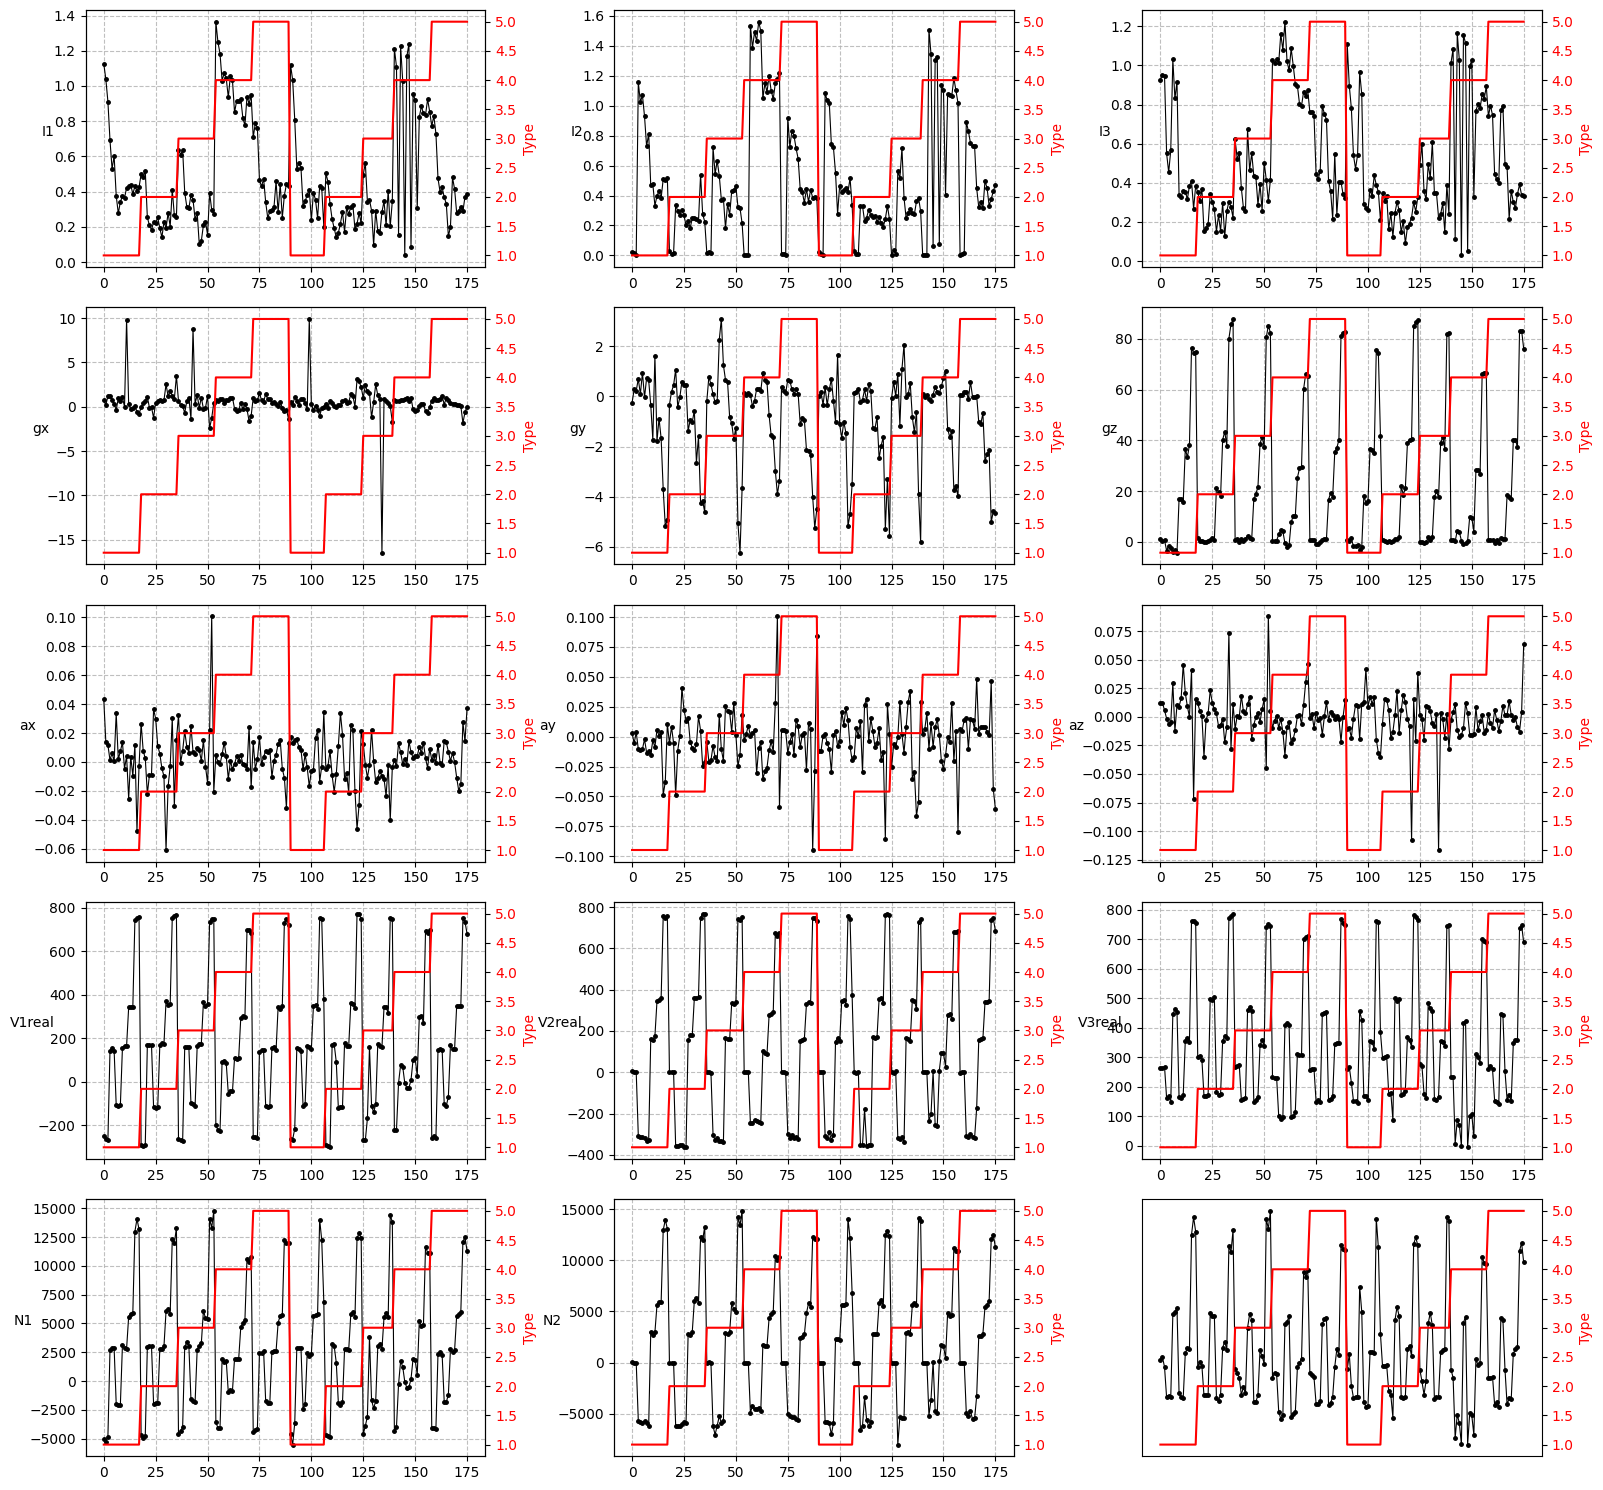

In [107]:
num_columns = V1.select_dtypes(include=np.number).columns.tolist()
num_columns.remove('Type')

cols = 3
rows = len(num_columns) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 15))
axes = axes.flatten()

for i, col in enumerate(num_columns):
    ax = axes[i]
    
    # График признака (синий)
    ax.plot(V1.index, V1[col], marker='.', linestyle='-', markersize=5, linewidth=0.8, color='black', label=col)
    ax.set_ylabel(col, color='black', rotation=0)
    ax.tick_params(axis='y', labelcolor='black')
    ax.grid(True, linestyle='--', alpha=0.8)

    # Вторая ось для Type (красный)
    ax2 = ax.twinx()
    ax2.plot(V1.index, V1['Type'], linestyle='-', linewidth=1.5, color='red', label='Type')
    ax2.set_ylabel('Type', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

axes[len(axes) - 1].axis('off')
plt.tight_layout()
plt.show()

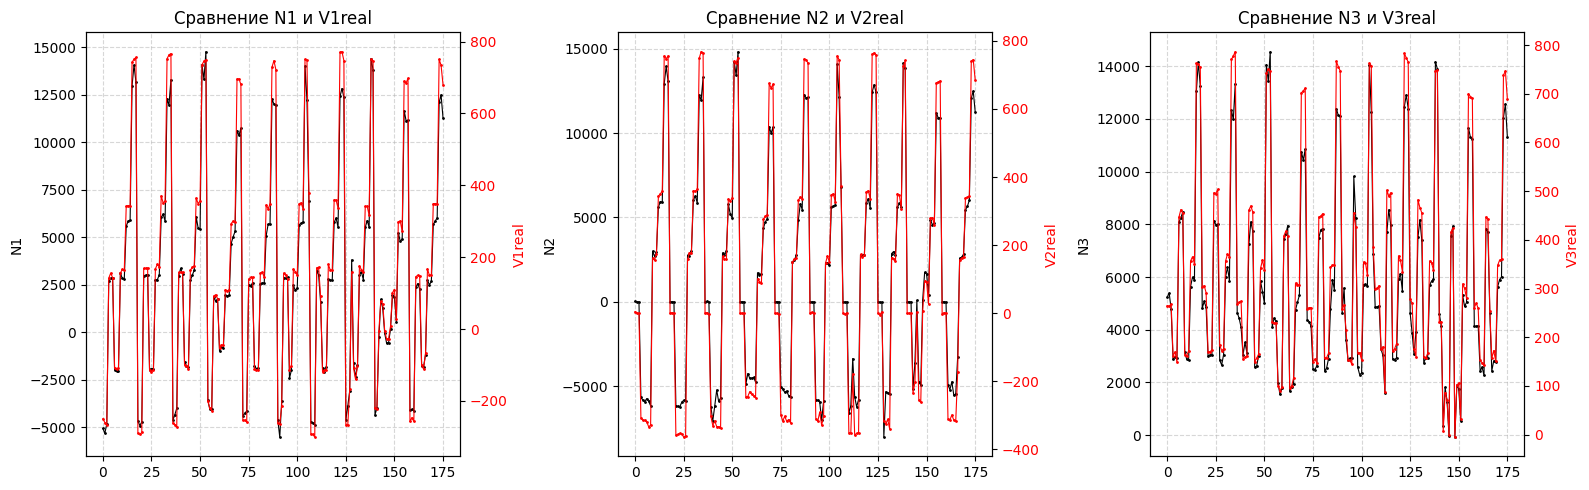

In [115]:
pairs = [('N1', 'V1real'), ('N2', 'V2real'), ('N3', 'V3real')]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (enc, vel) in zip(axes, pairs):
    # Ось для энкодера (синий)
    ax.plot(V1.index, V1[enc], color='black', marker='.', markersize=2, linewidth=0.8, label=enc)
    ax.set_ylabel(enc, color='black')
    ax.tick_params(axis='y', labelcolor='black')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Вторая ось для реальной скорости (красный)
    ax2 = ax.twinx()
    ax2.plot(V1.index, V1[vel], color='red', marker='.', markersize=2, linewidth=0.8, label=vel)
    ax2.set_ylabel(vel, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Общий заголовок
    ax.set_title(f'Сравнение {enc} и {vel}')

plt.tight_layout()
plt.show()

По результатам **первичного анализа** данных были сделаны следующие выводы:
1. Отсутствие NaN ячеек данных и дубликатов (все данные уникальны).
2. Датасет содержит 176 строк с информацией о данных датчиков для 5 типов поверхностей (что очень мало).
3. В датасете наблюдается дисбаланс классов при условии идентификации одного типа поверхности (36 строк для одной поверхности). 
4. Показания энкодеров [N1, N2, N3] практически эквиваленты данным [w1, w2, w3].
5. Показания датчиков тока (I1, I2, I3), гироскопа и акселерометра уникальны и практически отфильтрованы.

**Вывод**: В дальнейшем стоит рассмотреть вариант удаления показаний энкоредов. Всего 2 причины: практически полное соответствие [w1, w2, w3] и int64 представление (значения с датчика скорее всего округляются). В данных отсутствуют дубликаты и NaN заполнения, практически отсутствуют выбросы и данные скорее всего прошли фильтрацию.

### <font color='#F5DEB3'> 2. Работа над итоговым датасетом по варианту (V1+V3 для 5-го типа поверхности)

В данном этапе необходимо **объединить множества** V1 и V3, также нужно **провести бинаризацию** для 5-го типа поверхности.

In [120]:
def compute_V2_V3(V1, config):
    l = config['robot']['dist_center']
    r = config['robot']['wheel_radius']
    theta_degree = config['robot']['wheel_angle']

    theta = np.radians(theta_degree)         # угол установки колёс
    alpha = 0
    n = V1.shape[0]                # массив углов поворота робота
    
    # Знаки скоростей вращения для коррекции знаков токов
    omega_arr = V1[['V1real', 'V2real', 'V3real']].values
    sign_omega = np.sign(omega_arr)


    # Создаём массивы для матриц (n,3,3)
    M_vel = np.zeros((n, 3, 3))
    M_curr = np.zeros((n, 3, 3))

    # ----- Матрица скоростей -----
    M_vel[:,0,0] = - (2/3) * np.cos(alpha - theta)
    M_vel[:,0,1] =   (2/3) * np.sin(alpha)
    M_vel[:,0,2] =   (2/3) * np.cos(alpha + theta)
    
    M_vel[:,1,0] = - (2/3) * np.sin(alpha - theta)
    M_vel[:,1,1] = - (2/3) * np.cos(alpha)
    M_vel[:,1,2] =   (2/3) * np.sin(alpha + theta)
    
    M_vel[:,2,0] = 1/(3*l)
    M_vel[:,2,1] = 1/(3*l)
    M_vel[:,2,2] = 1/(3*l)

    M_curr[:,0,:] = M_vel[:,0,:]
    M_curr[:,1,:] = M_vel[:,1,:]
    M_curr[:,2,0] = 1/3
    M_curr[:,2,1] = 1/3
    M_curr[:,2,2] = 1/3


    # ----- Вычисление Vx, Vy, Ω -----
    V = np.einsum('ijk,ik->ij', M_vel, omega_arr) * r   # (n,3)

    # ----- Вычисление Ix, Iy, Iφ -----
    I_arr = V1[['I1', 'I2', 'I3']].values
    I_signed = I_arr * sign_omega
    I_vec = np.einsum('ijk,ik->ij', M_curr, I_signed)   # (n,3)

    # ----- IΣ (суммарная трудоёмкость) -----
    I_sum = np.sum(np.abs(I_vec), axis=1)

    # ----- Вычисление V3 (относительные параметры) -----
    eps = 1e-6
    Tx = V[:,0] / (I_vec[:,0] + eps)
    Ty = V[:,1] / (I_vec[:,1] + eps)
    Tphi = V[:,2] / (I_vec[:,2] + eps)
    Tz = V1['gz'].values / (I_vec[:,2] + eps)

    # Формируем DataFrame V2
    V2 = pd.DataFrame({
        'Vx': V[:,0],
        'Vy': V[:,1],
        'Ω': V[:,2],
        'Ix': I_vec[:,0],
        'Iy': I_vec[:,1],
        'Iφ': I_vec[:,2],
        'IΣ': I_sum
    }, index=V1.index)

    # Формируем DataFrame V3
    V3 = pd.DataFrame({
        'Tx': Tx,
        'Ty': Ty,
        'Tφ': Tphi,
        'Tz': Tz
    }, index=V1.index)

    return V2, V3

def prepare_target(V, target_col, type_space):
    V_pr = V.copy()
    
    # Бинарное преобразование
    V_pr[target_col] = (V_pr[target_col] == type_space).astype(int)
    
    other_cols = [col for col in V_pr.columns if col != target_col]
    V_pr = V_pr[other_cols + [target_col]]
    
    return V_pr

In [121]:
V2, V3 = compute_V2_V3(V1, config)
display(V2.head(), V3.head())

,Vx,Vy,Ω,Ix,Iy,Iφ,IΣ
0,11.883906,0.084706,2.202353,1.186050,-0.080443,-0.059327,1.325819
1,12.103979,0.042353,0.338824,1.150346,-0.028657,-0.028657,1.207661
2,12.397408,0.000000,0.000000,1.072844,0.012066,0.012066,1.096977
3,0.476823,12.218824,-0.338824,-0.081857,1.185520,0.028658,1.296035
4,0.330109,12.727059,1.185882,-0.043541,1.010559,-0.013575,1.067674


,Tx,Ty,Tφ,Tz
0,10.019730,-1.053009,-37.123142,-18.234364
1,10.522023,-1.477956,-11.823647,-16.934911
2,11.555636,0.000000,0.000000,55.034155
3,-5.825169,10.306711,-11.822603,-119.395980
4,-7.581752,12.594071,-87.364630,106.778993


In [122]:
type_space = config['data']['type_space']
target_col = config['data']['target_column']
V13 = pd.concat([V1, V3], axis=1)

##V13 = prepare_target(V13, target_col, type_space)

display(V13.info(), V13.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I1      176 non-null    float64
 1   I2      176 non-null    float64
 2   I3      176 non-null    float64
 3   gx      176 non-null    float64
 4   gy      176 non-null    float64
 5   gz      176 non-null    float64
 6   ax      176 non-null    float64
 7   ay      176 non-null    float64
 8   az      176 non-null    float64
 9   V1real  176 non-null    float64
 10  V2real  176 non-null    float64
 11  V3real  176 non-null    float64
 12  N1      176 non-null    int64  
 13  N2      176 non-null    int64  
 14  N3      176 non-null    int64  
 15  Type    176 non-null    int64  
 16  Tx      176 non-null    float64
 17  Ty      176 non-null    float64
 18  Tφ      176 non-null    float64
 19  Tz      176 non-null    float64
dtypes: float64(16), int64(4)
memory usage: 27.6 KB


None

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type,Tx,Ty,Tφ,Tz
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,1.760000e+02,1.760000e+02
mean,0.489130,0.496730,0.515435,0.489197,-0.918759,21.789526,0.002805,-0.002898,-0.000539,165.642524,104.380920,341.394548,2816.715909,1649.357955,5811.000000,3.011364,4.261262,4.885181,-9.233401e+03,-1.062304e+04
std,0.308620,0.408217,0.299098,1.937254,1.837406,28.148416,0.017431,0.024498,0.022011,314.381930,358.226896,210.213155,5370.894465,6209.505848,3557.591498,1.426238,23.653540,36.559139,1.247232e+05,1.417471e+05
min,0.037607,0.000000,0.029060,-16.461250,-6.236250,-4.251176,-0.060758,-0.094824,-0.116547,-300.600000,-363.600000,-4.764706,-5519.000000,-8010.000000,-72.000000,1.000000,-210.797359,-182.413471,-1.654468e+06,-1.880426e+06
25%,0.273050,0.241026,0.296795,-0.052768,-1.613667,0.552147,-0.004743,-0.012504,-0.009770,-108.450000,-257.294118,168.023077,-1830.750000,-4892.000000,2914.500000,2.000000,-3.904578,-3.626834,-2.623559e+01,-8.299547e+00
50%,0.383629,0.383760,0.403419,0.488000,-0.189101,6.161208,0.002562,0.000008,0.000168,155.647059,57.375000,300.600000,2732.500000,1022.500000,4895.500000,3.000000,0.000000,-0.838241,8.347827e+01,4.368113e+01
75%,0.696154,0.727800,0.780141,0.873414,0.276618,37.439714,0.012108,0.008070,0.009354,344.250000,339.621429,450.140625,5674.000000,5621.750000,7796.000000,4.000000,15.221840,13.800126,2.963580e+02,1.108520e+02
max,1.365008,1.561085,1.223229,9.905385,3.088000,87.827333,0.100601,0.100656,0.087982,772.200000,768.600000,786.600000,14770.000000,14829.000000,14554.000000,5.000000,60.296070,294.351259,1.058544e+03,4.893803e+02


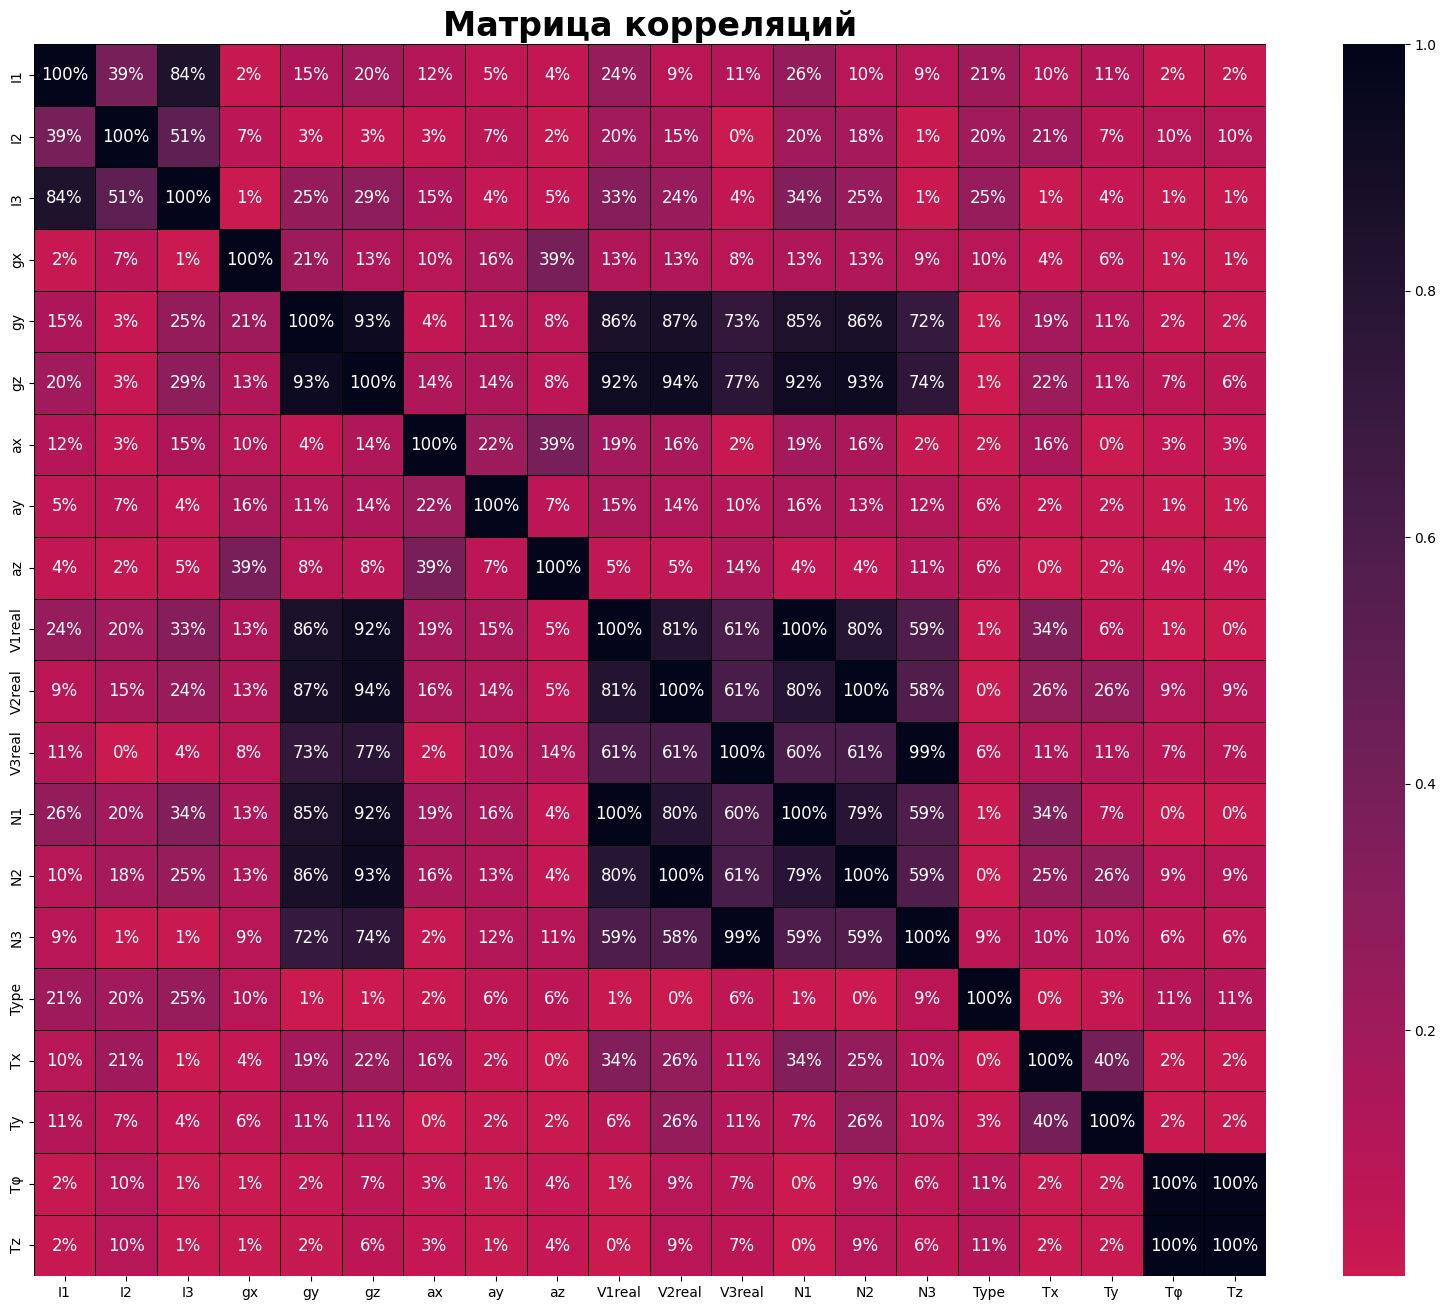

In [123]:
num_columns = V13.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(20, 16))
sns.heatmap(abs(V13[num_columns].corr()), 
            annot=True, 
            cbar=True,
            cmap='rocket_r', 
            center=0,
            fmt='.0%',
            annot_kws={'size':str(12)},
            square=True,
            linewidths=0.5,
            linecolor='black')
plt.title('Матрица корреляций', fontdict={'fontsize': 24, 'fontweight': 'bold'})
plt.show()

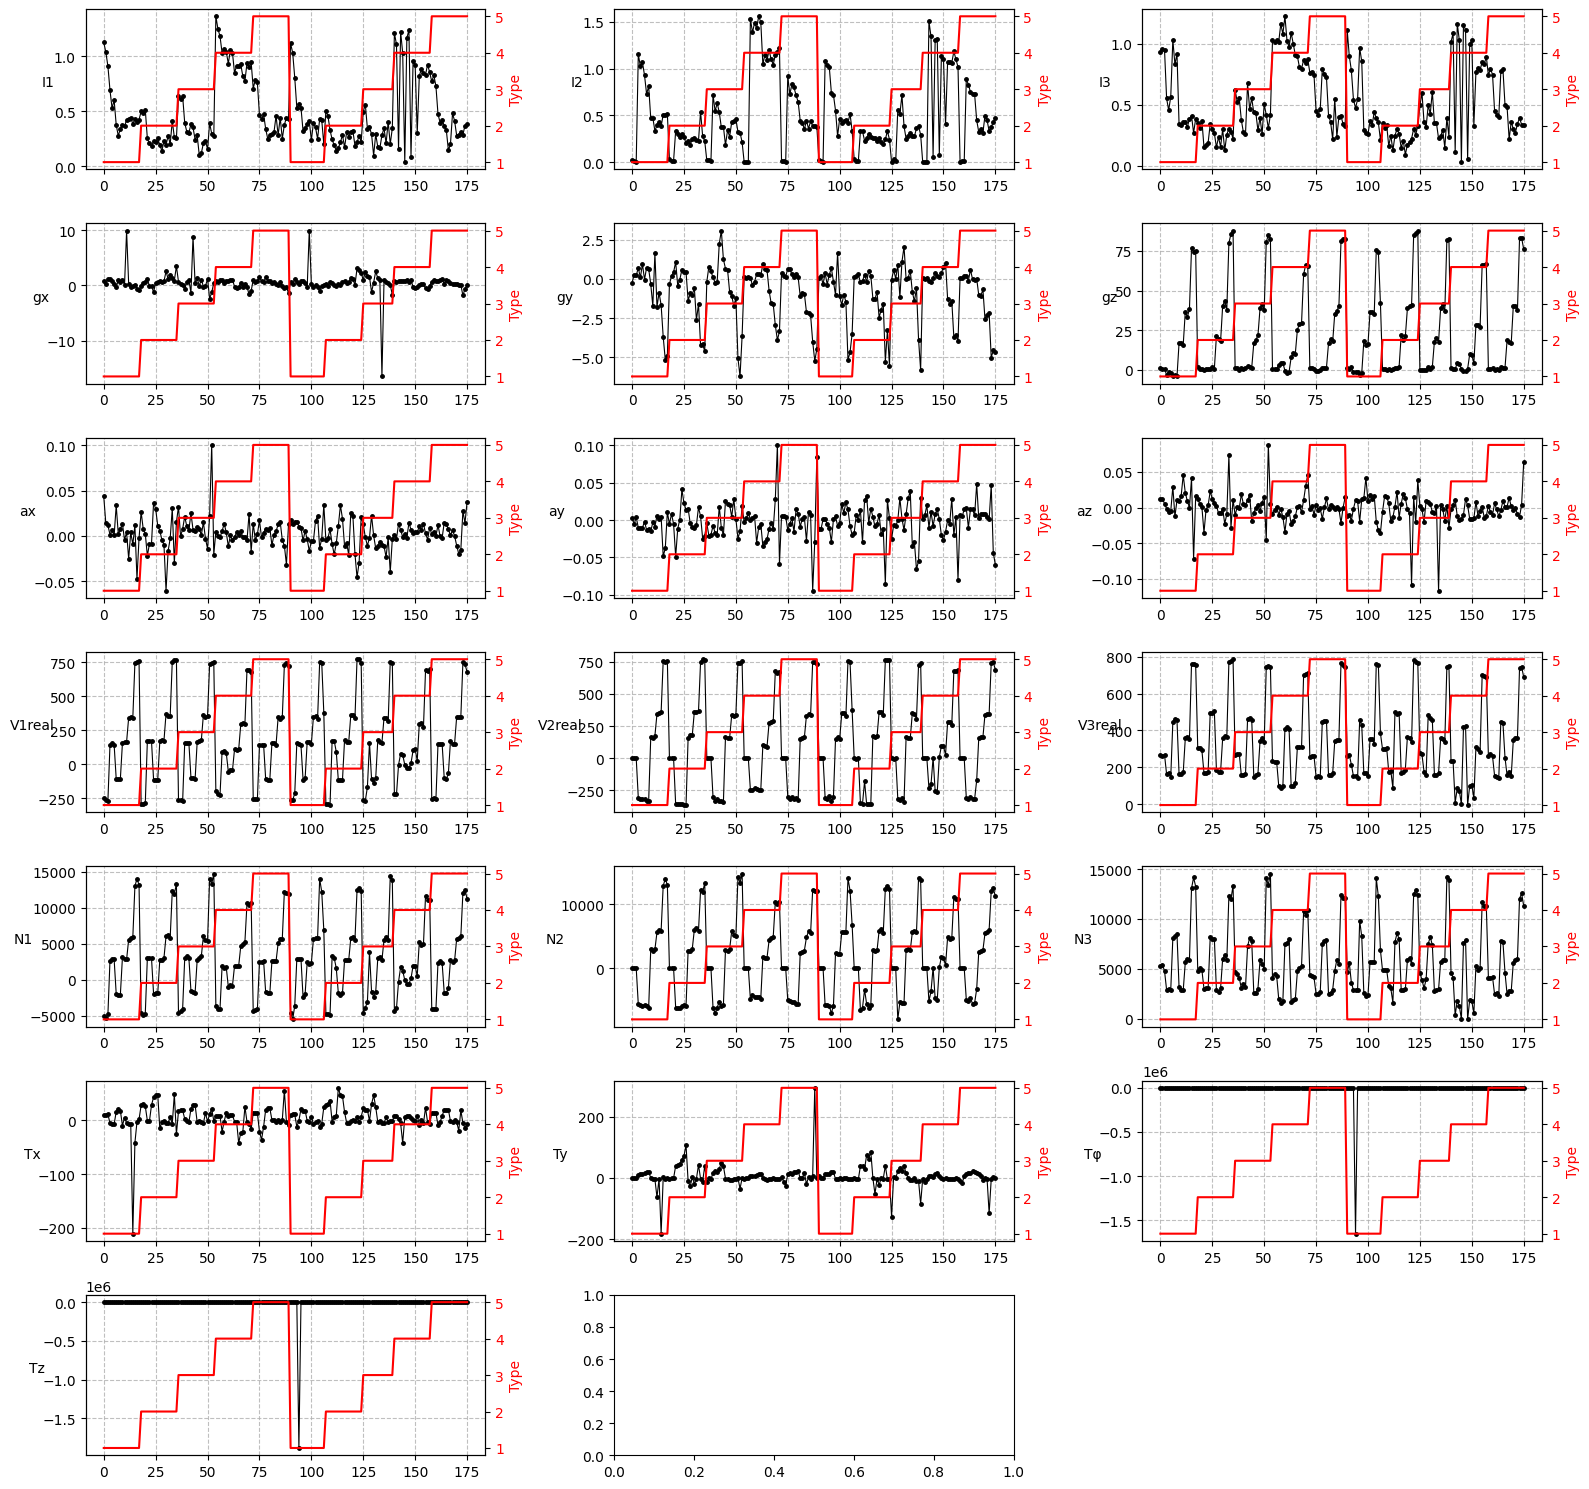

In [124]:
num_columns = V13.select_dtypes(include=np.number).columns.tolist()
num_columns.remove('Type')

cols = 3
rows = len(num_columns) // cols + 1
fig, axes = plt.subplots(rows, cols, figsize=(16, 15))
axes = axes.flatten()

for i, col in enumerate(num_columns):
    ax = axes[i]
    
    # График признака (синий)
    ax.plot(V13.index, V13[col], marker='.', linestyle='-', markersize=5, linewidth=0.8, color='black', label=col)
    ax.set_ylabel(col, color='black', rotation=0)
    ax.tick_params(axis='y', labelcolor='black')
    ax.grid(True, linestyle='--', alpha=0.8)

    # Вторая ось для Type (красный)
    ax2 = ax.twinx()
    ax2.plot(V13.index, V13['Type'], linestyle='-', linewidth=1.5, color='red', label='Type')
    ax2.set_ylabel('Type', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

axes[len(axes) - 1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
pairs = [('N1', 'V1real'), ('N2', 'V2real'), ('N3', 'V3real')]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (enc, vel) in zip(axes, pairs):
    # Ось для энкодера (синий)
    ax.plot(V13.index, V1[enc], color='black', marker='.', markersize=2, linewidth=0.8, label=enc)
    ax.set_ylabel(enc, color='black')
    ax.tick_params(axis='y', labelcolor='black')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Вторая ось для реальной скорости (красный)
    ax2 = ax.twinx()
    ax2.plot(V1.index, V1[vel], color='red', marker='.', markersize=2, linewidth=0.8, label=vel)
    ax2.set_ylabel(vel, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Общий заголовок
    ax.set_title(f'Сравнение {enc} и {vel}')

plt.tight_layout()
plt.show()

In [ ]:
V13 = pd.concat([V1, V3], axis=1)

# V13 = prepare_target(V13, target_col, type_space)

display(V13)

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Tx,Ty,Tφ,Tz,Type
0,1.126697,0.021116,0.927601,0.712941,-0.252941,1.081765,0.043529,0.003174,0.011661,-249.352941,4.764706,265.235294,-5070,30,5239,10.019739,-1.052996,-37.122516,-18.234056,0
1,1.039215,0.015083,0.953243,0.229412,0.276471,0.485294,0.013672,-0.005572,0.012164,-260.470588,0.000000,263.647059,-5320,-9,5391,10.522032,-1.477904,-11.823234,-16.934320,0
2,0.911011,0.004525,0.947210,1.170588,0.222941,0.664118,0.011704,0.003720,0.005744,-268.411765,0.000000,268.411765,-4829,6,4786,11.555647,0.000000,0.000000,55.038716,0
3,0.692308,1.156862,0.550528,1.165294,0.698235,-3.421765,0.001321,-0.010311,-0.001522,141.352941,-306.529412,162.000000,2670,-5662,2875,-5.825098,10.306720,-11.823016,-119.400146,0
4,0.529412,1.024133,0.453997,0.808235,0.090000,-1.449412,0.006218,-0.010986,-0.006247,155.647059,-314.470588,169.941176,2841,-5824,2967,-7.581578,12.594084,-87.358195,106.771127,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,0.288889,0.449573,0.270085,0.153333,-2.288667,40.140000,-0.019906,0.003939,-0.000586,349.200000,340.200000,358.200000,5847,5663,5901,-19.145413,-3.174873,332.391205,119.399547,1
172,0.314530,0.331624,0.341880,0.096000,-2.154667,37.425333,-0.015479,0.000993,-0.009017,347.400000,343.800000,360.000000,6025,6018,6005,18.427433,-115.832488,340.458078,113.635818,1
173,0.287179,0.377778,0.391453,-1.820667,-5.030000,82.963333,0.027490,0.046403,-0.012874,750.600000,739.800000,738.000000,12100,12073,12049,-4.833444,-4.679977,675.010683,235.599826,1
174,0.370940,0.427350,0.336752,-0.624000,-4.574000,83.285333,0.014160,-0.043896,0.003906,734.400000,745.200000,747.000000,12493,12493,12564,-14.742041,2.448839,627.740459,220.129233,1


In [65]:
processed_path = config['data']['dataset_processed']

os.makedirs(processed_path, exist_ok=True)
V13.to_excel(os.path.join(processed_path, 'Data_Set_AB_processed.xlsx'), index=False)

In [129]:
V_all = pd.concat([V1, V2, V3], axis=1)

type_space = config['data']['type_space']
target_col = config['data']['target_column']
#V_all = prepare_target(V_all, target_col, type_space)

V_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I1      176 non-null    float64
 1   I2      176 non-null    float64
 2   I3      176 non-null    float64
 3   gx      176 non-null    float64
 4   gy      176 non-null    float64
 5   gz      176 non-null    float64
 6   ax      176 non-null    float64
 7   ay      176 non-null    float64
 8   az      176 non-null    float64
 9   V1real  176 non-null    float64
 10  V2real  176 non-null    float64
 11  V3real  176 non-null    float64
 12  N1      176 non-null    int64  
 13  N2      176 non-null    int64  
 14  N3      176 non-null    int64  
 15  Type    176 non-null    int64  
 16  Vx      176 non-null    float64
 17  Vy      176 non-null    float64
 18  Ω       176 non-null    float64
 19  Ix      176 non-null    float64
 20  Iy      176 non-null    float64
 21  Iφ      176 non-null    float64
 22  IΣ

In [130]:
display(V_all.describe()) 

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,...,Vy,Ω,Ix,Iy,Iφ,IΣ,Tx,Ty,Tφ,Tz
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,...,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,1.760000e+02,1.760000e+02
mean,0.489130,0.496730,0.515435,0.489197,-0.918759,21.789526,0.002805,-0.002898,-0.000539,165.642524,...,3.977003,65.217919,0.243464,0.194410,0.206637,0.806257,4.261262,4.885181,-9.233401e+03,-1.062304e+04
std,0.308620,0.408217,0.299098,1.937254,1.837406,28.148416,0.017431,0.024498,0.022011,314.381930,...,5.787794,84.397536,0.407742,0.431410,0.318048,0.528890,23.653540,36.559139,1.247232e+05,1.417471e+05
min,0.037607,0.000000,0.029060,-16.461250,-6.236250,-4.251176,-0.060758,-0.094824,-0.116547,-300.600000,...,-0.336000,-7.488000,-0.151986,-0.227716,-0.532931,0.081541,-210.797359,-182.413471,-1.654468e+06,-1.880426e+06
25%,0.273050,0.241026,0.296795,-0.052768,-1.613667,0.552147,-0.004743,-0.012504,-0.009770,-108.450000,...,0.048000,0.768000,-0.022437,-0.058342,-0.013701,0.441407,-3.904578,-3.626834,-2.623559e+01,-8.299547e+00
50%,0.383629,0.383760,0.403419,0.488000,-0.189101,6.161208,0.002562,0.000008,0.000168,155.647059,...,0.255750,23.040000,0.021219,-0.003989,0.205128,0.595526,0.000000,-0.838241,8.347827e+01,4.368113e+01
75%,0.696154,0.727800,0.780141,0.873414,0.276618,37.439714,0.012108,0.008070,0.009354,344.250000,...,11.607882,110.777143,0.457192,0.356009,0.362678,1.107284,15.221840,13.800126,2.963580e+02,1.108520e+02
max,1.365008,1.561085,1.223229,9.905385,3.088000,87.827333,0.100601,0.100656,0.087982,772.200000,...,14.832000,247.296000,1.380242,1.801709,1.031517,2.761938,60.296070,294.351259,1.058544e+03,4.893803e+02


In [131]:
display(V_all.duplicated().sum(), V_all.isnull().sum())

np.int64(0)

I1        0
I2        0
I3        0
gx        0
gy        0
gz        0
ax        0
ay        0
az        0
V1real    0
V2real    0
V3real    0
N1        0
N2        0
N3        0
Type      0
Vx        0
Vy        0
Ω         0
Ix        0
Iy        0
Iφ        0
IΣ        0
Tx        0
Ty        0
Tφ        0
Tz        0
dtype: int64

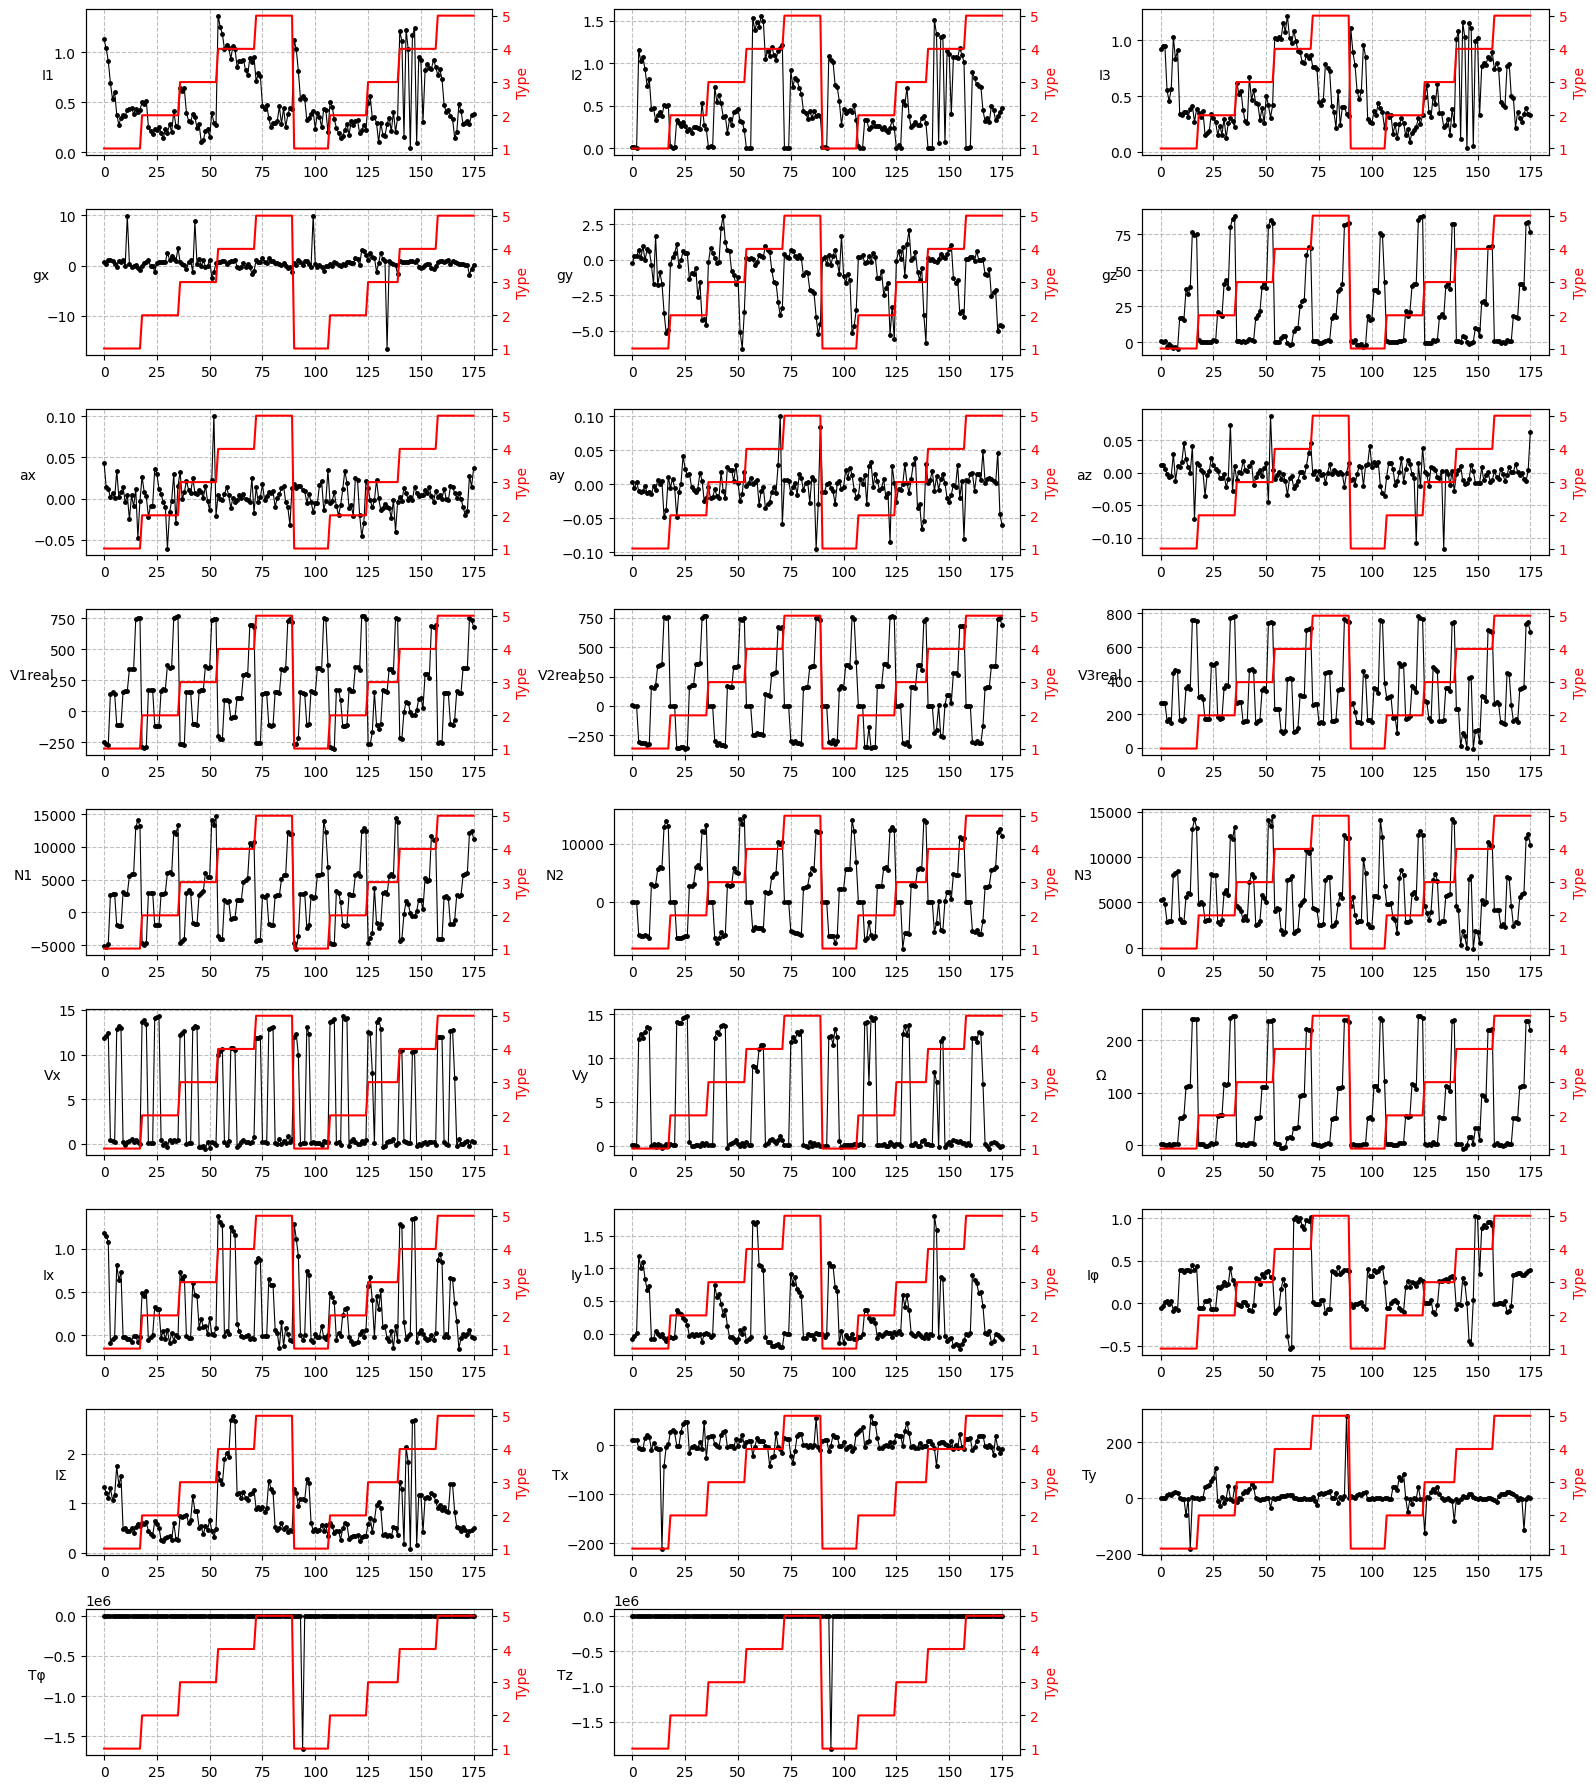

In [135]:
num_columns = V_all.select_dtypes(include=np.number).columns.tolist()
num_columns.remove('Type')

cols = 3
rows = len(num_columns) // cols + 1
fig, axes = plt.subplots(rows, cols, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(num_columns):
    ax = axes[i]
    
    # График признака (синий)
    ax.plot(V_all.index, V_all[col], marker='.', linestyle='-', markersize=5, linewidth=0.8, color='black', label=col)
    ax.set_ylabel(col, color='black', rotation=0)
    ax.tick_params(axis='y', labelcolor='black')
    ax.grid(True, linestyle='--', alpha=0.8)

    # Вторая ось для Type (красный)
    ax2 = ax.twinx()
    ax2.plot(V_all.index, V_all['Type'], linestyle='-', linewidth=1.5, color='red', label='Type')
    ax2.set_ylabel('Type', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

axes[len(axes) - 1].axis('off')
plt.tight_layout()
plt.show()

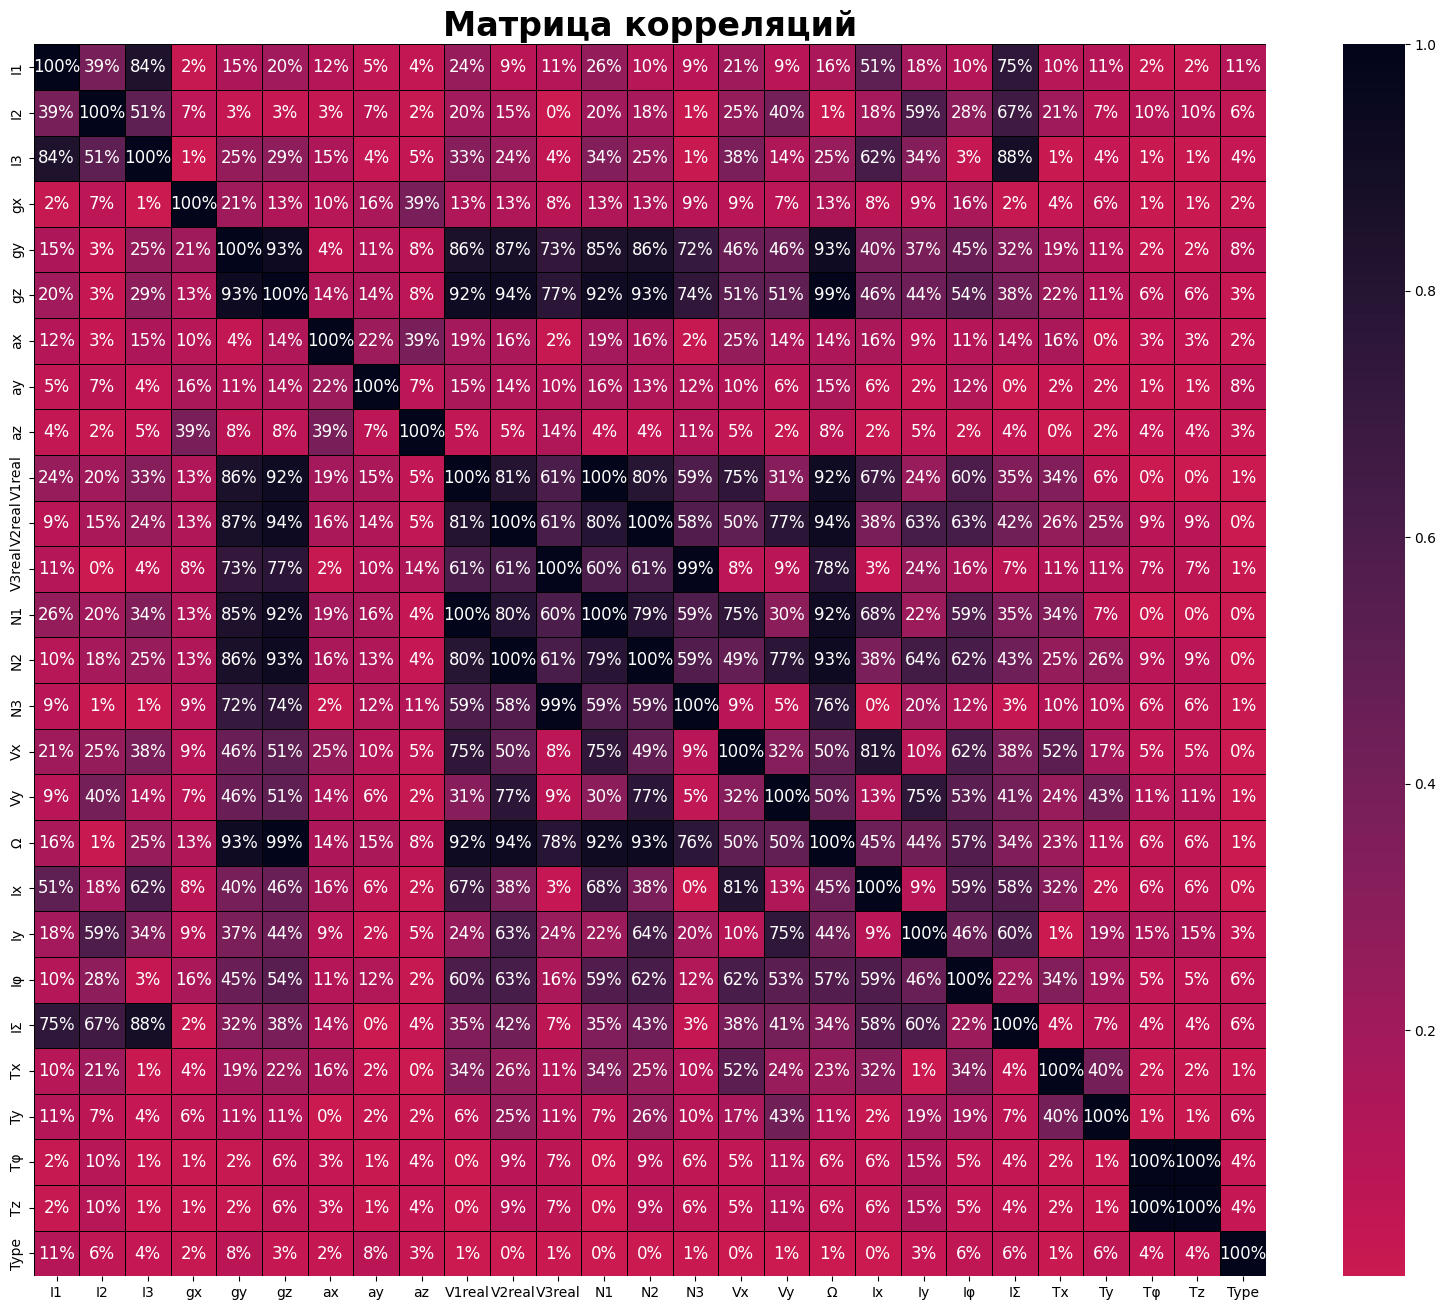

In [ ]:
num_columns = V_all.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(20, 16))
sns.heatmap(abs(V_all[num_columns].corr()), 
            annot=True, 
            cbar=True,
            cmap='rocket_r', 
            center=0,
            fmt='.0%',
            annot_kws={'size':str(12)},
            square=True,
            linewidths=0.5,
            linecolor='black')
plt.title('Матрица корреляций', fontdict={'fontsize': 24, 'fontweight': 'bold'})
plt.show()